[2026-03-01 15:53:24] === 3銘柄をランダムに選択 ===
選ばれた3銘柄:
 - BNB
 - DOGE
 - SOL
[2026-03-01 15:53:24] Fetching BNB ...
[2026-03-01 15:53:25] Fetching DOGE ...
[2026-03-01 15:53:26] Fetching SOL ...


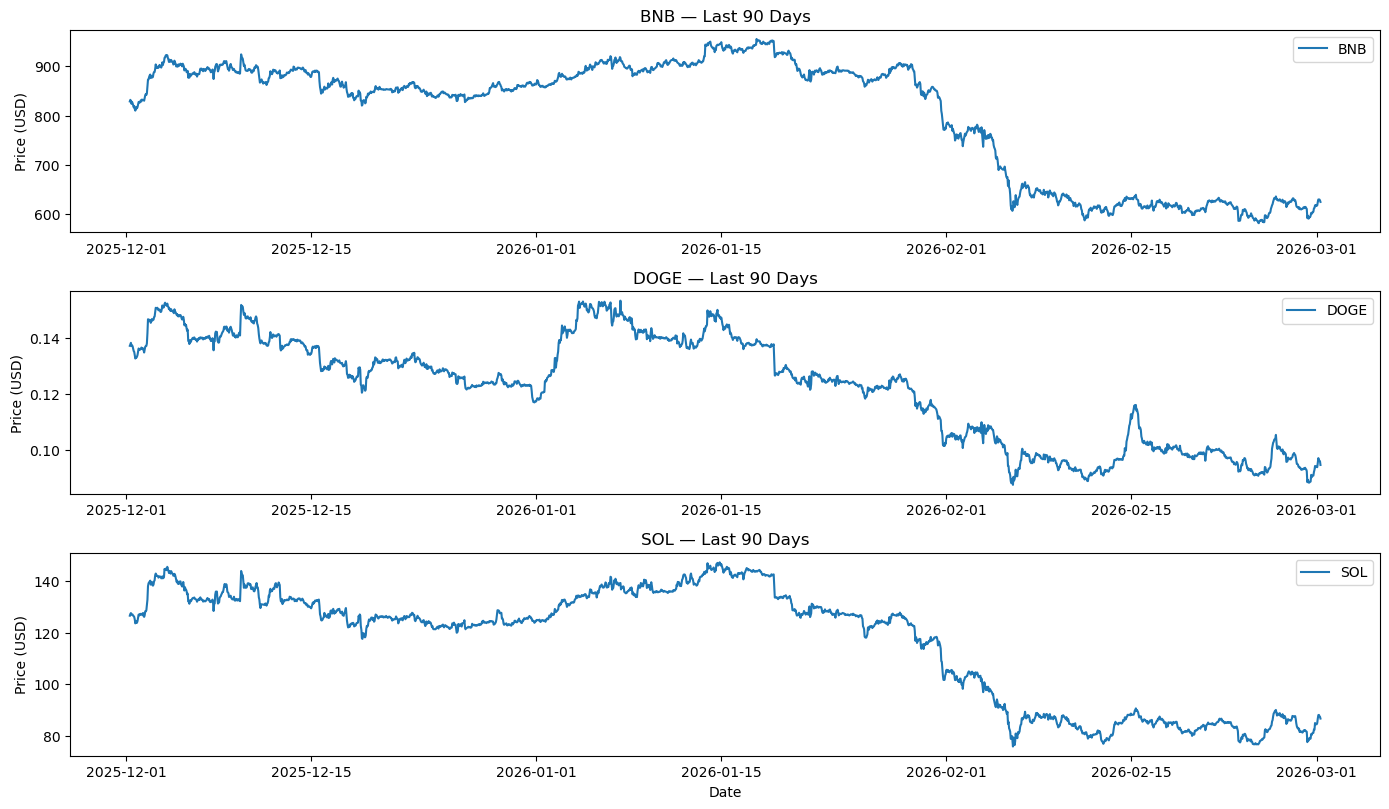

[2026-03-01 15:53:28] === 価格そのものに AR を適用（in-sample 予測） ===
[2026-03-01 15:53:28] Applying AR on PRICE for BNB ...
[2026-03-01 15:53:28] [BNB] Fitting AR(5) on price (length=2161)
[2026-03-01 15:53:28] [BNB] in-sample (last 50 pts) MSE=1.601371e+01, RMSE=4.001714e+00


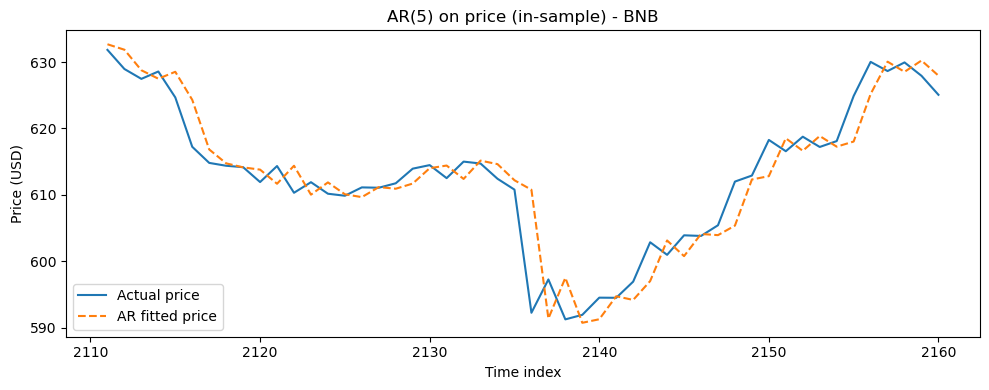

[2026-03-01 15:53:28] Applying AR on PRICE for DOGE ...
[2026-03-01 15:53:28] [DOGE] Fitting AR(5) on price (length=2161)
[2026-03-01 15:53:28] [DOGE] in-sample (last 50 pts) MSE=8.418659e-07, RMSE=9.175325e-04


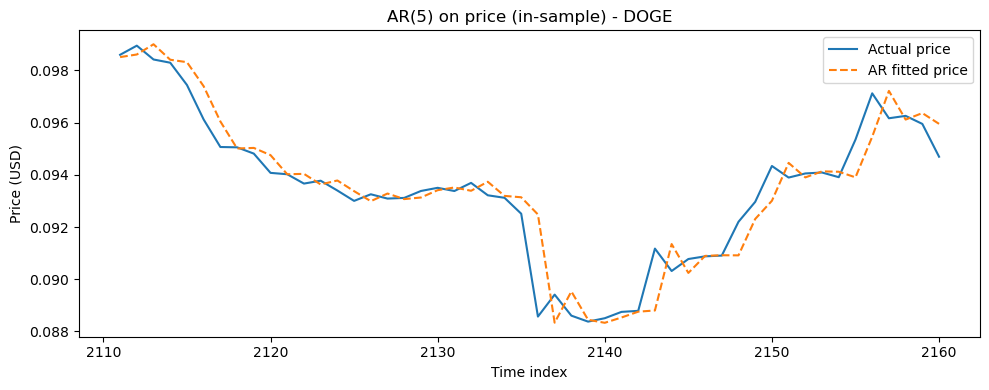

[2026-03-01 15:53:29] Applying AR on PRICE for SOL ...
[2026-03-01 15:53:29] [SOL] Fitting AR(5) on price (length=2161)
[2026-03-01 15:53:29] [SOL] in-sample (last 50 pts) MSE=9.365077e-01, RMSE=9.677333e-01


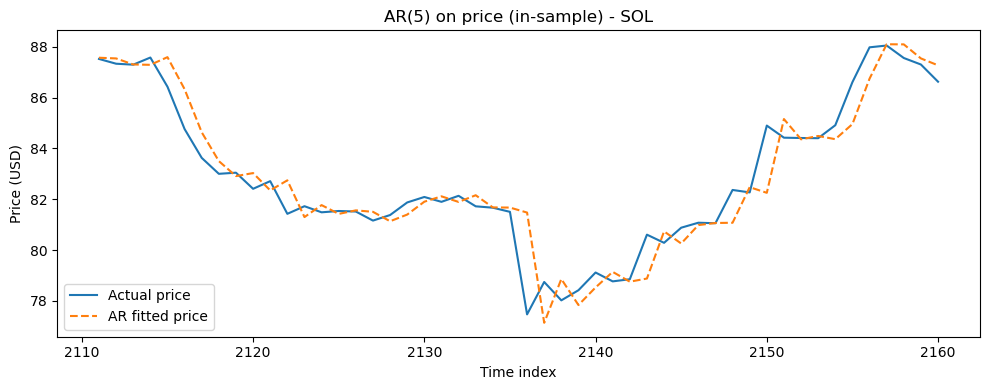

In [2]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    """
    CoinGecko から指定銘柄の market_chart データを取得して
    timestamp, price の DataFrame を返す。
    """
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.sort_values("timestamp")
    return df


# ------------------------
# 価格そのものに AR を当てて「1ステップ先予測」を見る
# ------------------------
def apply_ar_price_in_sample(df: pd.DataFrame, symbol: str, lags: int = 5):
    """
    価格そのものに AR(lags) をフィットして、
    ・in-sample の 1 ステップ先予測 (fitted values) を取得
    ・末尾の一部区間で、実データと重ねてプロットする
    """
    # index = 0,1,... にしておく
    series = pd.Series(df["price"].values.astype(float))

    log(f"[{symbol}] Fitting AR({lags}) on price (length={len(series)})")
    model = AutoReg(series, lags=lags, old_names=False)
    res = model.fit()

    # fittedvalues は「lags 番目以降」の時点に対する 1 ステップ先予測
    fitted = res.fittedvalues      # index: lags .. N-1
    actual = series[lags:]         # 同じく lags .. N-1
    N = len(series)

    # 共通のインデックス  lags .. N-1
    idx = np.arange(lags, N)

    # 末尾 tail 点だけ表示（多すぎると見づらいので最大50点）
    tail = min(50, len(idx))
    idx_tail = idx[-tail:]
    actual_tail = actual.iloc[-tail:]
    fitted_tail = fitted.iloc[-tail:]

    # 念のため長さを揃える（保険）
    min_len = min(len(idx_tail), len(actual_tail), len(fitted_tail))
    idx_tail = idx_tail[-min_len:]
    actual_tail = actual_tail.iloc[-min_len:]
    fitted_tail = fitted_tail.iloc[-min_len:]

    # 評価（in-sample, 末尾区間）
    mse = ((actual_tail.values - fitted_tail.values) ** 2).mean()
    rmse = np.sqrt(mse)
    log(f"[{symbol}] in-sample (last {min_len} pts) MSE={mse:.6e}, RMSE={rmse:.6e}")

    # プロット
    plt.figure(figsize=(10, 4))
    plt.plot(idx_tail, actual_tail.values, label="Actual price")
    plt.plot(idx_tail, fitted_tail.values, "--", label="AR fitted price")
    plt.title(f"AR({lags}) on price (in-sample) - {symbol}")
    plt.xlabel("Time index")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# メイン処理：3選択 → 価格プロット → 価格に AR
# ------------------------
def main():
    log("=== 3銘柄をランダムに選択 ===")

    # 3つランダムに選択
    selected = random.sample(COINS_POOL, 3)
    print("選ばれた3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    # ---------- 価格プロット ----------
    plt.figure(figsize=(14, 8))
    dfs = {}

    for idx, (coin_id, symbol) in enumerate(selected, start=1):
        log(f"Fetching {symbol} ...")
        df = fetch_market_chart(coin_id, DAYS, VS)
        dfs[symbol] = df

        plt.subplot(3, 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.ylabel(f"Price ({VS.upper()})")
        plt.legend()
        plt.tight_layout()

        time.sleep(0.5)

    plt.xlabel("Date")
    plt.show()

    # ---------- 価格に AR(=in-sample 1step) を適用 ----------
    log("=== 価格そのものに AR を適用（in-sample 予測） ===")

    for symbol, df in dfs.items():
        log(f"Applying AR on PRICE for {symbol} ...")
        apply_ar_price_in_sample(df, symbol)
        time.sleep(0.5)


if __name__ == "__main__":
    main()